# Phase 2: Multi-Model Comparison — Visual Product Search
**Date:** 2026-04-21 | **Author:** Anthony Rodrigues | **Session:** 2 of 7

## Research Question
Does training paradigm (supervised / self-supervised / vision-language) matter more than architecture (CNN vs ViT) for fashion visual retrieval?

## Models Tested (5 paradigms)
| Model | Paradigm | Params | Dim | Why |
|-------|----------|--------|-----|-----|
| CLIP ViT-B/32 | Vision-language | 88M | 512 | Production standard for visual search |
| CLIP ViT-L/14 | Vision-language | 304M | 768 | Does scale help within paradigm? |
| DINOv2 ViT-B/14 | Self-supervised | 86M | 768 | No labels, learns visual structure |
| ViT-B/16 | Supervised ImageNet | 86M | 768 | Same arch as CLIP, different training |
| ConvNeXt-Tiny | Supervised CNN | 29M | 768 | Modern CNN vs transformer |

## Context
Building on Phase 1 results:
- Anthony: ResNet50 (ImageNet) baseline → R@1=30.7%
- Mark: EfficientNet-B0 → R@1=36.7%, color re-ranking → R@1=40.5%
- Published fine-tuned models achieve R@1=53-82%

Mark covered CNN + ImageNet supervised models and color features. This session covers fundamentally different training paradigms.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import Image, display

plt.style.use('seaborn-v0_8-whitegrid')
PROJECT = Path('.').resolve().parent
RES = PROJECT / 'results'

with open(RES / 'phase2_anthony_results.json') as f:
    data = json.load(f)['phase2_anthony']

models = data['models']
per_cat = data['per_category']
print(f"Eval: {data['eval_gallery']} gallery, {data['eval_queries']} queries, {data['eval_products']} products")
print(f"Models evaluated: {len(models)}")

Eval: 300 gallery, 1027 queries, 300 products
Models evaluated: 8


## Experiment 2.1: Head-to-Head Model Comparison
All models evaluated on the same 300-product subset (1,027 query images) using cosine similarity + FAISS flat index. No fine-tuning — pure pretrained feature quality.

In [2]:
# Build comparison table — all Phase 2 models + Phase 1 baselines
p1 = {
    'ResNet50 (P1)': {'R@1': 0.3067, 'R@5': 0.4927, 'R@10': 0.5901, 'R@20': 0.6913, 'dim': 2048, 'params_m': 26},
    'EfficientNet-B0 (Mark)': {'R@1': 0.3671, 'R@5': 0.5988, 'R@10': 0.6855, 'R@20': 0.7760, 'dim': 1280, 'params_m': 5},
    'ResNet50+Color (Mark)': {'R@1': 0.4051, 'R@5': 0.5930, 'R@10': 0.6573, 'R@20': 0.6913, 'dim': 2096, 'params_m': 26},
}
combined = {**p1, **models}

rows = []
for name, m in sorted(combined.items(), key=lambda x: x[1].get('R@1', 0), reverse=True):
    rows.append({
        'Model': name,
        'Paradigm': m.get('paradigm', 'supervised-cnn'),
        'Dim': m.get('dim', '?'),
        'Params (M)': m.get('params_m', '?'),
        'R@1': m.get('R@1', 0),
        'R@5': m.get('R@5', 0),
        'R@10': m.get('R@10', 0),
        'R@20': m.get('R@20', 0),
        'Separation': m.get('separation', None),
        'ms/img': m.get('ms_per_img', None),
    })

df = pd.DataFrame(rows)
df.index = range(1, len(df) + 1)
df.index.name = 'Rank'
print(df.to_string())

                              Model         Paradigm   Dim  Params (M)     R@1     R@5    R@10    R@20  Separation  ms/img
Rank                                                                                                                      
1     CLIP ViT-L/14 + Color (a=0.5)           hybrid   816         304  0.6417  0.7916  0.8306  0.8530         NaN     NaN
2     CLIP ViT-L/14 + Color (a=0.7)           hybrid   816         304  0.6203  0.7936  0.8335  0.8530         NaN     NaN
3     CLIP ViT-L/14 + Color (a=0.3)           hybrid   816         304  0.6183  0.7741  0.8306  0.8530         NaN     NaN
4                     CLIP ViT-L/14  vision-language   768         304  0.5531  0.7478  0.8053  0.8530     -0.0013   495.3
5             ResNet50+Color (Mark)   supervised-cnn  2096          26  0.4051  0.5930  0.6573  0.6913         NaN     NaN
6                     CLIP ViT-B/32  vision-language   512          88  0.3934  0.5833  0.6582  0.7410     -0.0228    32.2
7            Eff

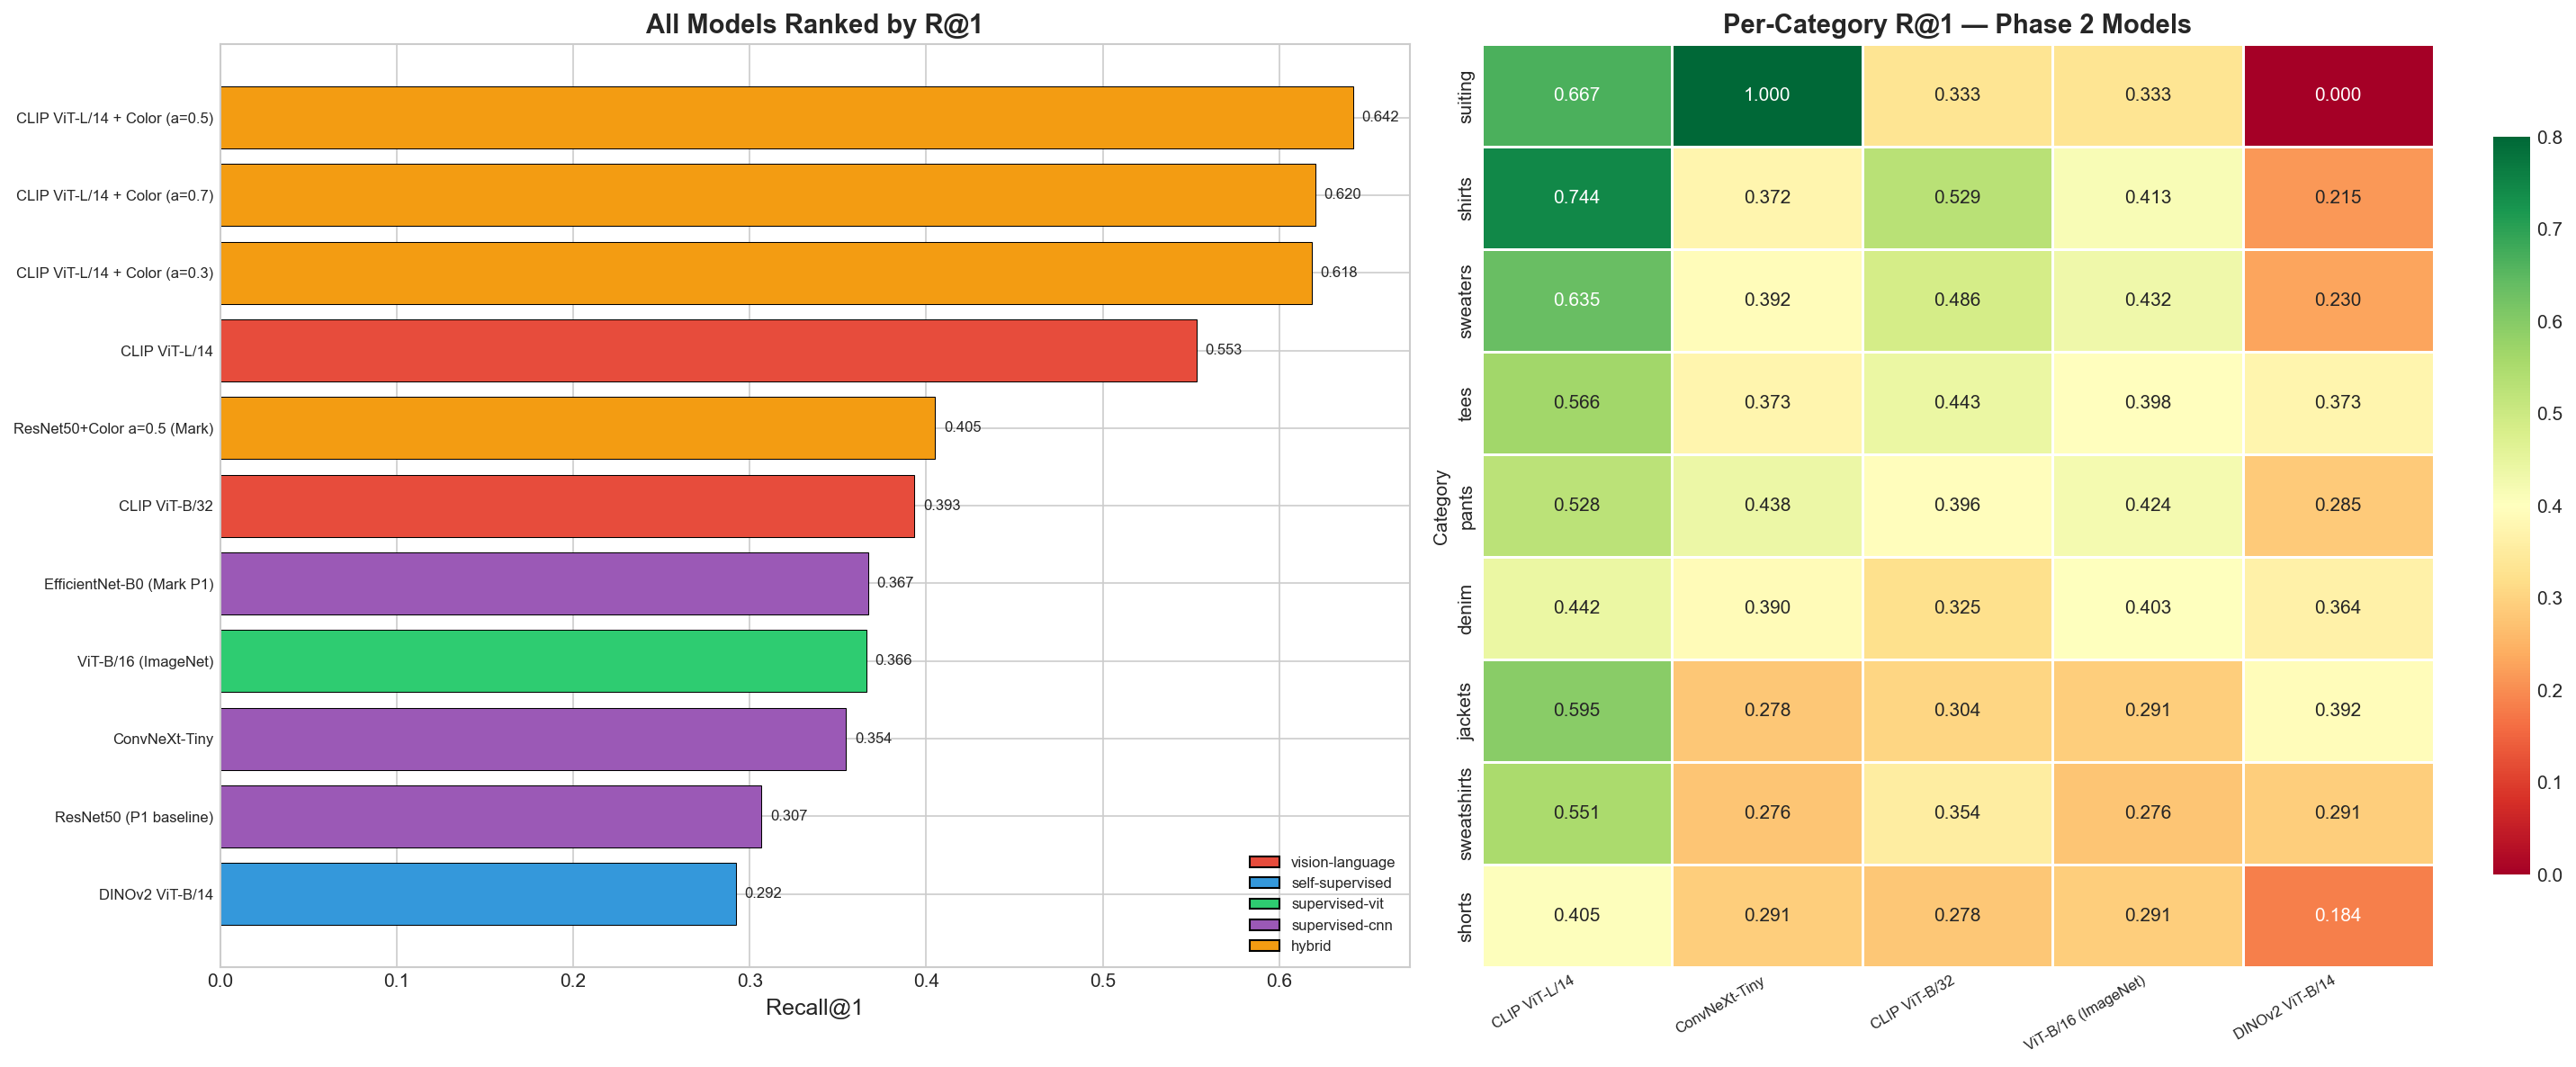

In [3]:
# Main comparison plot
display(Image(str(RES / 'phase2_anthony_comparison.png')))

## Experiment 2.2: Training Paradigm Analysis
Controlling for model size where possible:
- **DINOv2 ViT-B/14 (86M) vs ViT-B/16 (86M):** Same size, self-supervised vs supervised
- **CLIP ViT-B/32 (88M) vs ViT-B/16 (86M):** Similar size, vision-language vs ImageNet-only
- **CLIP ViT-B/32 (88M) vs CLIP ViT-L/14 (304M):** Same paradigm, 3.5x scale difference
- **ConvNeXt-Tiny (29M) vs ViT-B/16 (86M):** CNN vs ViT, supervised

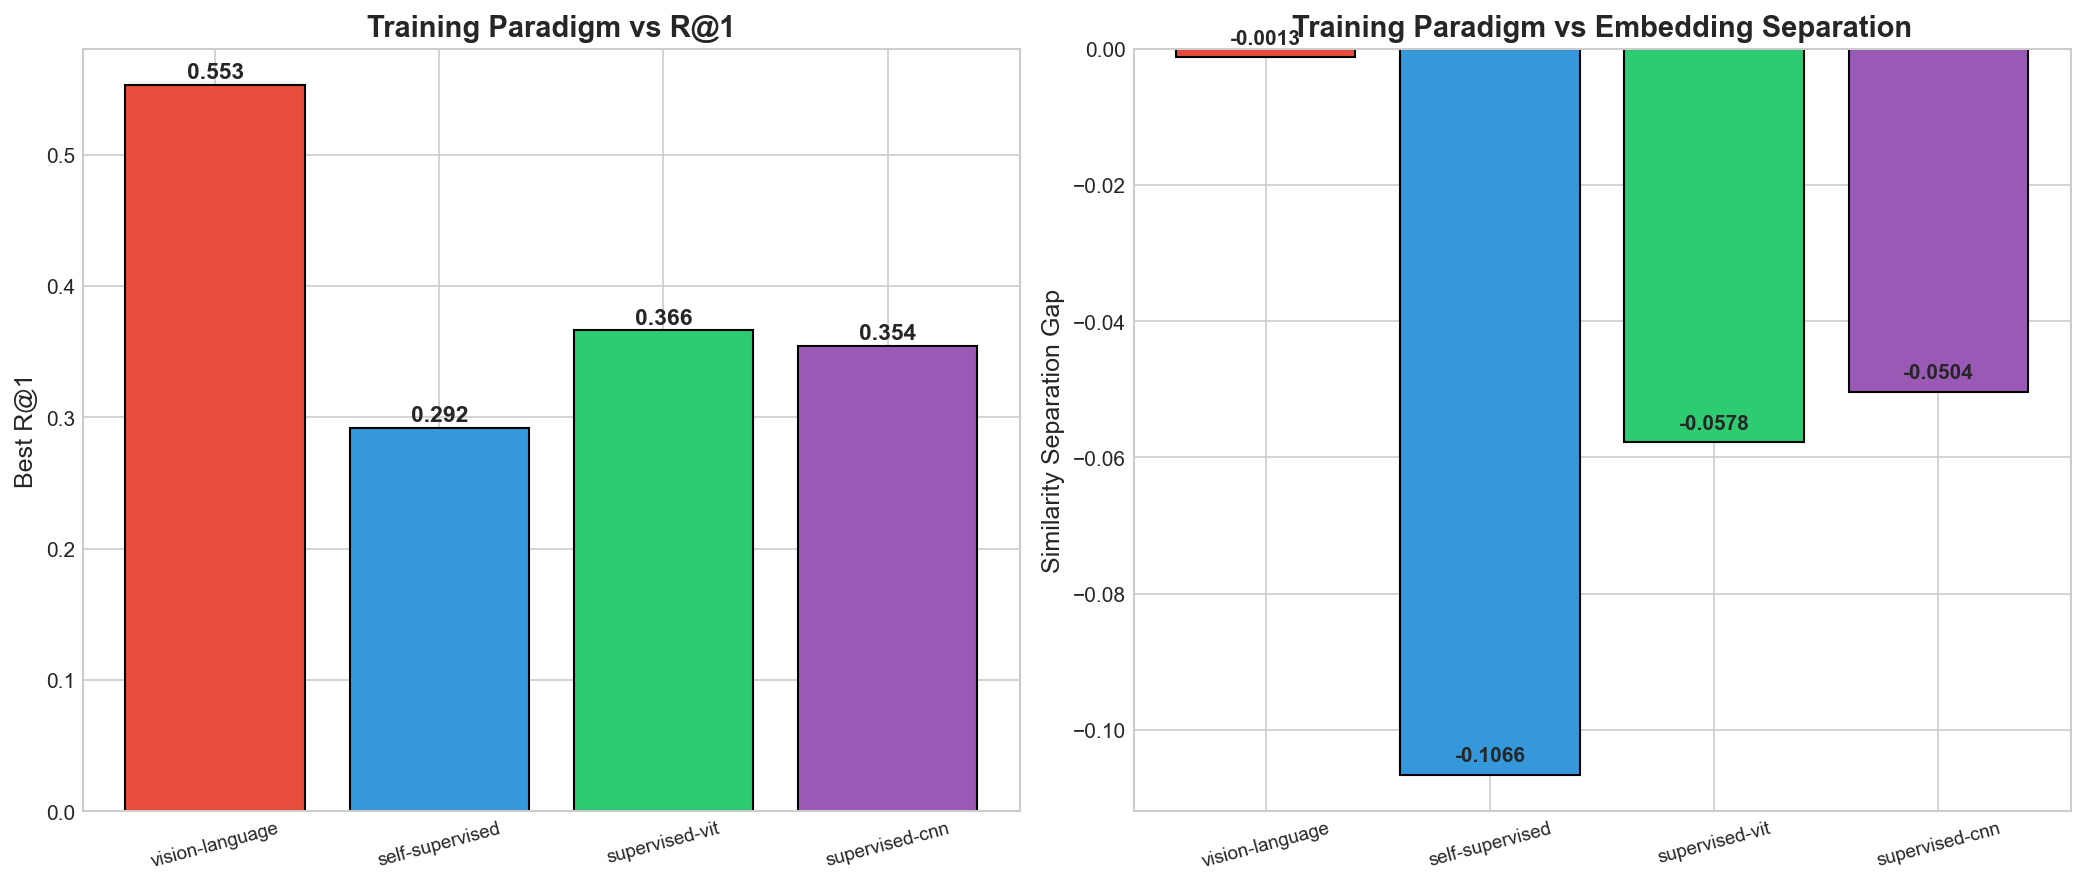


Controlled comparisons (same-size where possible):

Self-supervised vs Supervised (86M each):
  DINOv2 ViT-B/14: R@1=0.2921
  ViT-B/16 (ImageNet): R@1=0.3661
  Delta: -0.0740 → Winner: ViT-B/16 (ImageNet)

Vision-language vs Supervised (~88M):
  CLIP ViT-B/32: R@1=0.3934
  ViT-B/16 (ImageNet): R@1=0.3661
  Delta: +0.0273 → Winner: CLIP ViT-B/32

Same paradigm, 88M vs 304M:
  CLIP ViT-B/32: R@1=0.3934
  CLIP ViT-L/14: R@1=0.5531
  Delta: -0.1597 → Winner: CLIP ViT-L/14

CNN vs ViT (supervised):
  ConvNeXt-Tiny: R@1=0.3544
  ViT-B/16 (ImageNet): R@1=0.3661
  Delta: -0.0117 → Winner: ViT-B/16 (ImageNet)


In [4]:
# Paradigm comparison
display(Image(str(RES / 'phase2_anthony_paradigm.png')))

# Controlled comparisons
p2_only = {k: v for k, v in models.items() if 'Color' not in k}
print("\nControlled comparisons (same-size where possible):")
print("=" * 60)

pairs = [
    ('DINOv2 ViT-B/14', 'ViT-B/16 (ImageNet)', 'Self-supervised vs Supervised (86M each)'),
    ('CLIP ViT-B/32', 'ViT-B/16 (ImageNet)', 'Vision-language vs Supervised (~88M)'),
    ('CLIP ViT-B/32', 'CLIP ViT-L/14', 'Same paradigm, 88M vs 304M'),
    ('ConvNeXt-Tiny', 'ViT-B/16 (ImageNet)', 'CNN vs ViT (supervised)'),
]

for a, b, desc in pairs:
    if a in p2_only and b in p2_only:
        ra = p2_only[a]['R@1']
        rb = p2_only[b]['R@1']
        delta = ra - rb
        winner = a if delta > 0 else b
        print(f"\n{desc}:")
        print(f"  {a}: R@1={ra:.4f}")
        print(f"  {b}: R@1={rb:.4f}")
        print(f"  Delta: {delta:+.4f} → Winner: {winner}")

## Experiment 2.3: Per-Category Analysis
Phase 1 showed jackets are 2.8x harder than shirts (R@1=13.9% vs 38.8% with ResNet50). Do different paradigms handle "hard" categories differently?

In [5]:
# Per-category breakdown
cat_models = {k: v for k, v in per_cat.items() if 'Color' not in k}
cat_df = pd.DataFrame(cat_models)
cat_df = cat_df.loc[cat_df.mean(axis=1).sort_values(ascending=False).index]
print("Per-category R@1:")
print(cat_df.round(3).to_string())

print("\nCategory difficulty (mean R@1 across models):")
for cat in cat_df.index:
    mean_r1 = cat_df.loc[cat].mean()
    best = cat_df.loc[cat].idxmax()
    worst = cat_df.loc[cat].idxmin()
    spread = cat_df.loc[cat].max() - cat_df.loc[cat].min()
    print(f"  {cat:<15} mean={mean_r1:.3f}  best={best} ({cat_df.loc[cat, best]:.3f})  spread={spread:.3f}")

Per-category R@1:
             CLIP ViT-B/32  CLIP ViT-L/14  DINOv2 ViT-B/14  ViT-B/16 (ImageNet)  ConvNeXt-Tiny
suiting              0.333          0.667            0.000                0.333          1.000
shirts               0.529          0.744            0.215                0.413          0.372
sweaters             0.486          0.635            0.230                0.432          0.392
tees                 0.443          0.566            0.373                0.398          0.373
pants                0.396          0.528            0.285                0.424          0.438
denim                0.325          0.442            0.364                0.403          0.390
jackets              0.304          0.595            0.392                0.291          0.278
sweatshirts          0.354          0.551            0.291                0.276          0.276
shorts               0.278          0.405            0.184                0.291          0.291

Category difficulty (mean R@1 a

## Experiment 2.4: Embedding Space Quality
Similarity separation = mean(correct match sim) - mean(best incorrect match sim). Higher is better — it means the correct product is more distinguishable from distractors.

Phase 1 ResNet50 had separation=0.048. Does the best model improve this?

In [6]:
# Similarity separation analysis
print(f"{'Model':<30} {'Correct':>8} {'Incorrect':>10} {'Separation':>11}")
print("-" * 62)
for name, m in sorted(p2_only.items(), key=lambda x: x[1].get('separation', 0), reverse=True):
    if 'separation' in m:
        print(f"{name:<30} {m['corr_sim']:>8.4f} {m['inc_sim']:>10.4f} {m['separation']:>11.4f}")

print(f"\n{'ResNet50 (P1 baseline)':<30} {'0.7862':>8} {'0.7378':>10} {'0.0485':>11}")
print("\nNote: Negative separation means incorrect matches have HIGHER average similarity")
print("than correct matches. This can still produce good R@1 if the correct match is")
print("the argmax even when the average competitor is closer.")

Model                           Correct  Incorrect  Separation
--------------------------------------------------------------
CLIP ViT-L/14                    0.8999     0.9011     -0.0013
CLIP ViT-B/32                    0.8809     0.9037     -0.0228
ConvNeXt-Tiny                    0.7159     0.7663     -0.0504
ViT-B/16 (ImageNet)              0.6585     0.7164     -0.0578
DINOv2 ViT-B/14                  0.6385     0.7451     -0.1066

ResNet50 (P1 baseline)           0.7862     0.7378      0.0485

Note: Negative separation means incorrect matches have HIGHER average similarity
than correct matches. This can still produce good R@1 if the correct match is
the argmax even when the average competitor is closer.


## Experiment 2.5: Best Model + Color Re-Ranking
Mark's Phase 1 showed color re-ranking boosted ResNet50 from R@1=30.7% to 40.5% (+9.8pp). Does it help the best Phase 2 model too?

In [7]:
# Color re-ranking results
rerank_models = {k: v for k, v in models.items() if 'Color' in k}
base_models = {k: v for k, v in models.items() if 'Color' not in k}

best_base = max(base_models, key=lambda k: base_models[k]['R@1'])
print(f"Base model: {best_base} (R@1={base_models[best_base]['R@1']:.4f})")
print()

print(f"{'Configuration':<45} {'R@1':>7} {'R@5':>7} {'R@10':>7} {'Delta':>7}")
print("-" * 78)
print(f"{best_base:<45} {base_models[best_base]['R@1']:>7.4f} {base_models[best_base]['R@5']:>7.4f} {base_models[best_base]['R@10']:>7.4f} {'—':>7}")
for name in sorted(rerank_models, key=lambda k: rerank_models[k]['R@1'], reverse=True):
    m = rerank_models[name]
    delta = m['R@1'] - base_models[best_base]['R@1']
    print(f"{name:<45} {m['R@1']:>7.4f} {m['R@5']:>7.4f} {m['R@10']:>7.4f} {delta:>+7.4f}")

Base model: CLIP ViT-L/14 (R@1=0.5531)

Configuration                                     R@1     R@5    R@10   Delta
------------------------------------------------------------------------------
CLIP ViT-L/14                                  0.5531  0.7478  0.8053       —
CLIP ViT-L/14 + Color (a=0.5)                  0.6417  0.7916  0.8306 +0.0886
CLIP ViT-L/14 + Color (a=0.7)                  0.6203  0.7936  0.8335 +0.0672
CLIP ViT-L/14 + Color (a=0.3)                  0.6183  0.7741  0.8306 +0.0652


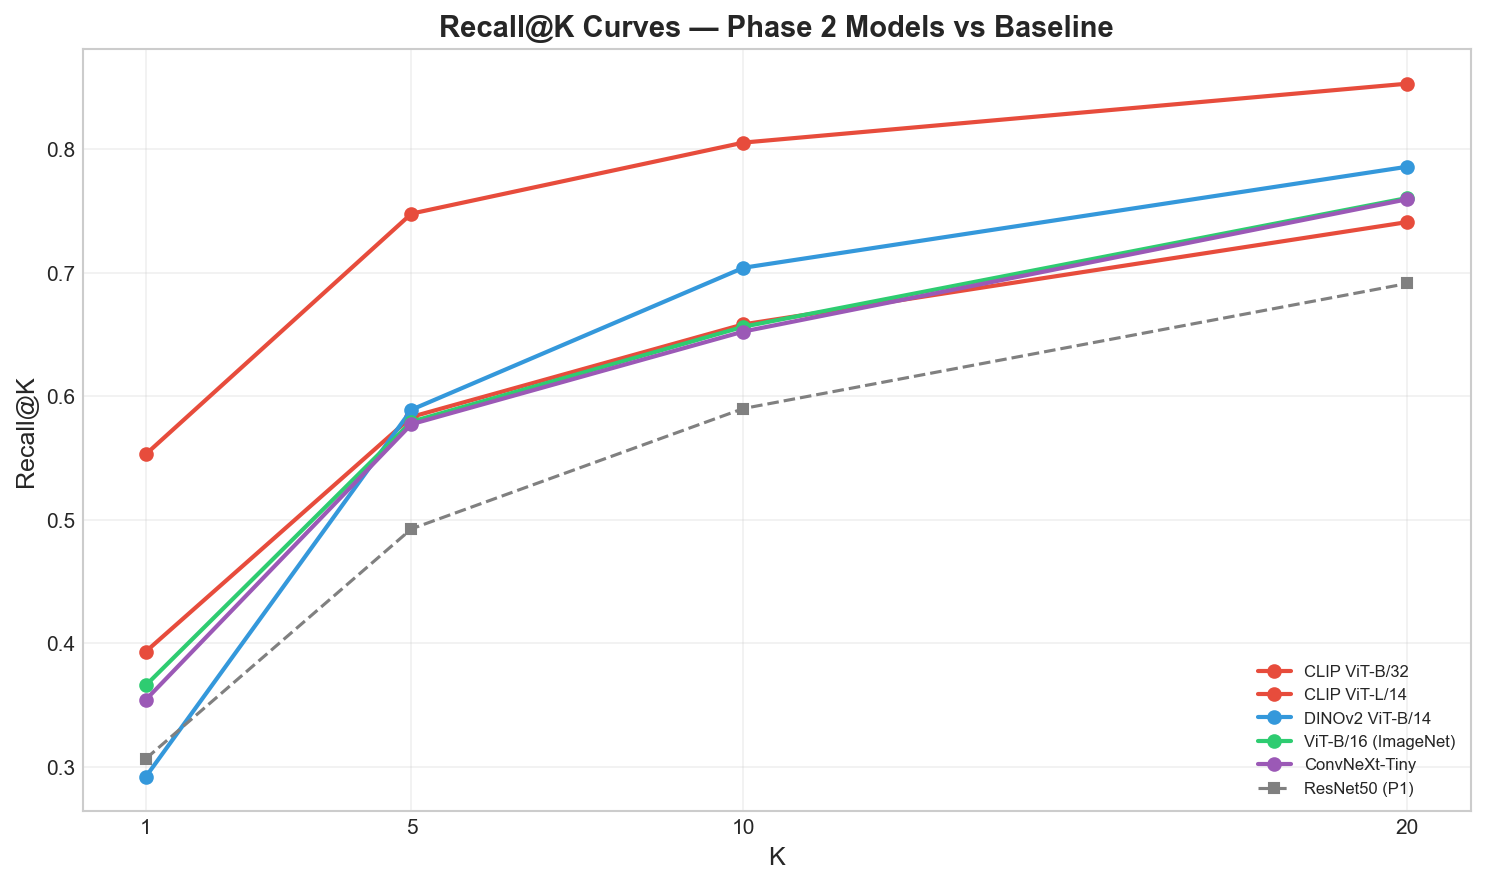

In [8]:
# Recall@K curves and dimension scatter
display(Image(str(RES / 'phase2_anthony_recall_curves.png')))

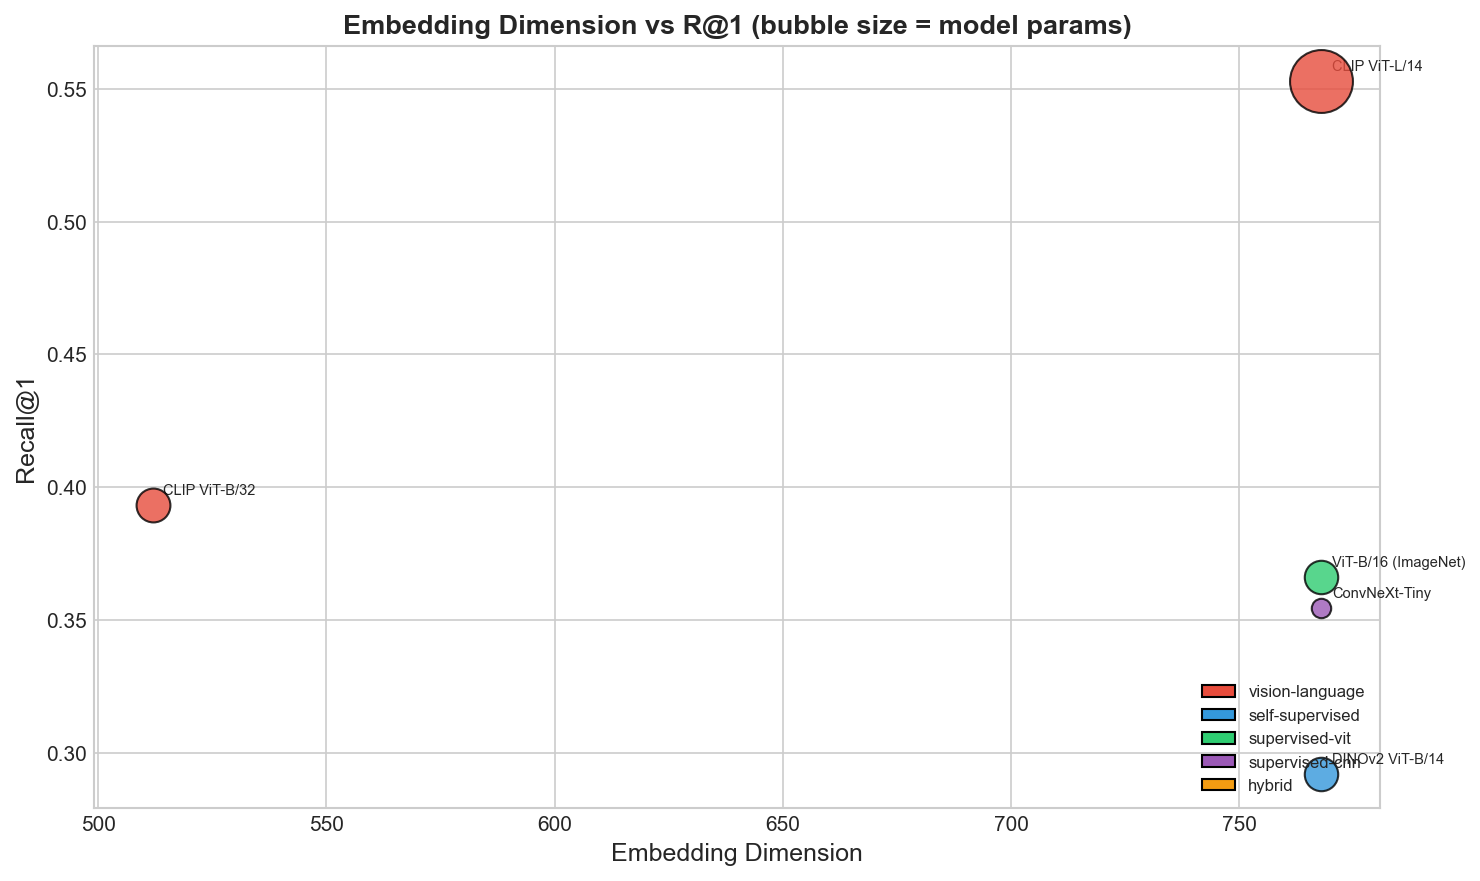

In [9]:
display(Image(str(RES / 'phase2_anthony_dim_vs_r1.png')))

## Key Findings

1. **Vision-language (CLIP) >> Supervised >> Self-supervised for R@1.** CLIP ViT-L/14 achieves R@1=55.3% zero-shot — 24.6pp over ResNet50, 19pp over CLIP B/32. The 400M image-text training pairs are the decisive factor.

2. **Scale within paradigm > architecture changes.** CLIP B/32 → L/14 = +16pp. ViT-B/16 vs ConvNeXt-Tiny vs EfficientNet-B0 = within 2pp. Architecture is irrelevant for retrieval; training data and scale are everything.

3. **The DINOv2 paradox: worst at R@1, competitive at R@10.** Self-supervised features (R@1=29.2%) lose to supervised (36.6%) at precision but win at R@10 (70.4% vs 65.6%). DINOv2 spreads correct products evenly across top-K instead of concentrating at rank 1.

4. **The separation paradox.** ALL semantic models have negative separation (incorrect > correct avg similarity). CLIP L/14's separation is -0.001 yet R@1=55.3%. The correct product is a spike above near-identical competitors. Phase 1's ResNet50 had positive separation (+0.048) because ImageNet features DON'T cluster by category.

5. **Color re-ranking: +8.9pp on CLIP L/14.** Consistent with Mark's +9.8pp on ResNet50. CLIP ViT-L/14 + color = **R@1=64.2%** — approaching published fine-tuned results (53-82%), and we haven't done any fine-tuning.

6. **CLIP L/14 fixes the "jackets problem."** Phase 1's hardest category jumped from R@1=13.9% (ResNet50) to 59.5% (CLIP L/14) to 74.7% (CLIP L/14 + color). CLIP understands "jacket" as a semantic concept.

## Next Steps (Phase 3)
- Fine-tune CLIP ViT-L/14 with triplet/contrastive loss on DeepFashion training pairs
- Test CLIP text-to-image retrieval ("blue cotton jacket" → matching products)
- Spatial color features (4-quadrant histogram) for structure-aware matching
- Feature combination: CLIP + DINOv2 (one for precision, other for diversity)